# H3 — Animal Symbolism and Social Perception in Prado Paintings

This notebook tests whether the presence and type of animals in Prado paintings are associated with differences in perceived warmth and competence.

The analysis is conducted at the painting level. It begins with a baseline comparison between paintings with and without fauna, and then refines the analysis by using iconographic animal tags extracted from the original database.

The goal is to evaluate whether different animal roles are linked to distinct social perception patterns in the Stereotype Content Model dimensions of warmth and competence.

In [1]:
import pandas as pd
import sqlite3

# Load strict final dataset
df_base = pd.read_csv("../Data/Processed/final_dataset_strict.csv")

# Rename target variables for convenience
df_base = df_base.rename(columns={
    "dirmean_Warmth": "warmth",
    "dirmean_Competence": "competence"
})

print("Loaded df_base ✅")
print("Shape:", df_base.shape)
print("\nColumns:")
print(df_base.columns.tolist())

Loaded df_base ✅
Shape: (3198, 19)

Columns:
['cat_no', 'titulo', 'autor', 'escuela_obra', 'tipo_objeto', 'datacion', 'tema', 'is_religious', 'is_fauna', 'century', 'image_path', 'descripcion', 'animal_cluster', 'n_descriptores_fila', 'n_en_diccionario_fila', 'warmth', 'n_dirmean_Warmth', 'competence', 'n_dirmean_Competence']


In [2]:
# Connect to original SQLite database
db_path = "/home/agrupa-lab/agrupa/agrupa.sqlite"
conn = sqlite3.connect(db_path)

print("Connected to SQLite DB ✅")

Connected to SQLite DB ✅


In [3]:
q = """
SELECT 
    at.cat_no,
    it.tag_id,
    it.name,
    it.slug,
    it.depth
FROM artwork_tag at
JOIN icon_tag it
    ON at.tag_id = it.tag_id
WHERE at.cat_no LIKE 'P%'
  AND it.slug LIKE 'fauna%'
"""

fauna_tags = pd.read_sql_query(q, conn)

print("Shape:", fauna_tags.shape)
print("\nUnique paintings with fauna tags:", fauna_tags["cat_no"].nunique())
print("\nSample:")
print(fauna_tags.head(20).to_string(index=False))

Shape: (5284, 5)

Unique paintings with fauna tags: 2542

Sample:
     cat_no  tag_id                           name                                         slug  depth
    P000002     133                           Pavo                              fauna/aves/pavo      2
    P000002     217 Perro (Canis lupus familiaris) fauna/mamiferos/perro-canis-lupus-familiaris      2
    P000002     125                         Paloma                            fauna/aves/paloma      2
    P000006      55                     Camachuelo                        fauna/aves/camachuelo      2
    P000013     206            León (Panthera leo)            fauna/mamiferos/leon-panthera-leo      2
    P000014     217 Perro (Canis lupus familiaris) fauna/mamiferos/perro-canis-lupus-familiaris      2
    P000015      93                     Golondrina                        fauna/aves/golondrina      2
P000015/001      93                     Golondrina                        fauna/aves/golondrina      2
P000015

In [4]:
top_fauna = (
    fauna_tags.groupby(["slug", "name", "depth"])["cat_no"]
    .nunique()
    .reset_index(name="n_artworks")
    .sort_values("n_artworks", ascending=False)
)

print(top_fauna.head(80).to_string(index=False))

                                        slug                           name  depth  n_artworks
fauna/mamiferos/perro-canis-lupus-familiaris Perro (Canis lupus familiaris)      2         780
                     fauna/mamiferos/caballo                        Caballo      2         706
            fauna/mamiferos/oveja-ovis-aries             Oveja (Ovis aries)      2         295
                                  fauna/aves                           Aves      1         188
                      fauna/mamiferos/bovido                         Bovido      2         165
          fauna/aves/paloma/blanca/simbolica                      simbólica      4         154
                        fauna/mamiferos/asno                           Asno      2         140
                            fauna/aves/gallo                          Gallo      2         118
                            fauna/artropodos                     Artropodos      1         113
           fauna/mamiferos/leon-panthera-leo      

### Constructing Animal Role Categories

Animal roles are derived using the hierarchical iconographic taxonomy provided in the Prado database.

Instead of relying on specific animal names alone, classification is based on semantic groupings inferred from tag slugs (e.g., mammals, birds, symbolic animals).

This allows for a more robust and generalizable categorization of animal roles across artworks.

In [7]:
# ---- Define categories manually ----

def classify_animal(slug):
    slug = slug.lower()
    
    if "simbolica" in slug:
        return "symbolic"
    
    if any(x in slug for x in ["perro", "caballo", "oveja", "bovido", "cabra", "asno", "mula"]):
        return "domestic"
    
    if any(x in slug for x in ["leon", "aguila", "tigre"]):
        return "power"
    
    if any(x in slug for x in ["ciervo", "conejo", "mono", "reptil", "pez"]):
        return "wild"
    
    return "other"


fauna_tags["animal_type"] = fauna_tags["slug"].apply(classify_animal)

print(fauna_tags["animal_type"].value_counts())

# ---- Aggregate to painting level ----

animal_pivot = (
    fauna_tags
    .pivot_table(index="cat_no", columns="animal_type", values="tag_id", aggfunc="count")
    .fillna(0)
)

# Convert counts to binary (presence)
animal_pivot = (animal_pivot > 0).astype(int)

# Reset index
animal_pivot = animal_pivot.reset_index()

print(animal_pivot.head())

animal_type
domestic    2368
other       2305
wild         263
power        194
symbolic     154
Name: count, dtype: int64
animal_type   cat_no  domestic  other  power  symbolic  wild
0            P000002         1      1      0         0     0
1            P000006         0      1      0         0     0
2            P000013         0      0      1         0     0
3            P000014         1      0      0         0     0
4            P000015         0      1      0         0     0


In [8]:
print(fauna_tags["animal_type"].value_counts())

animal_type
domestic    2368
other       2305
wild         263
power        194
symbolic     154
Name: count, dtype: int64


In [9]:
animal_pivot = (
    fauna_tags
    .pivot_table(
        index="cat_no",
        columns="animal_type",
        values="tag_id",
        aggfunc="count",
        fill_value=0
    )
)

# Convert counts to binary presence/absence
animal_pivot = (animal_pivot > 0).astype(int).reset_index()

print("Shape:", animal_pivot.shape)
print("\nColumns:", animal_pivot.columns.tolist())
print("\nPainting-level sums:")
print(animal_pivot.drop(columns="cat_no").sum())

print("\nSample:")
print(animal_pivot.head(10).to_string(index=False))

Shape: (2542, 6)

Columns: ['cat_no', 'domestic', 'other', 'power', 'symbolic', 'wild']

Painting-level sums:
animal_type
domestic    1594
other       1141
power        170
symbolic     154
wild         213
dtype: int64

Sample:
     cat_no  domestic  other  power  symbolic  wild
    P000002         1      1      0         0     0
    P000006         0      1      0         0     0
    P000013         0      0      1         0     0
    P000014         1      0      0         0     0
    P000015         0      1      0         0     0
P000015/001         0      1      0         1     0
    P000016         0      0      0         0     1
    P000018         1      0      0         0     0
    P000019         1      0      0         0     0
    P000021         1      1      1         0     1


In [10]:
# Make a copy so we keep the original safe
animal_pivot_merge = animal_pivot.copy()

# Normalize to base painting ID (e.g. P000015/001 -> P000015)
animal_pivot_merge["cat_no"] = animal_pivot_merge["cat_no"].astype(str).str.split("/").str[0]

# If multiple detail rows collapse into one painting, keep presence if any detail has it
animal_pivot_merge = (
    animal_pivot_merge
    .groupby("cat_no", as_index=False)[["domestic", "other", "power", "symbolic", "wild"]]
    .max()
)

# Merge into the strict final dataset
df_h3 = df_base.merge(animal_pivot_merge, on="cat_no", how="left")

# Fill paintings without fauna tags as 0
for col in ["domestic", "other", "power", "symbolic", "wild"]:
    df_h3[col] = df_h3[col].fillna(0).astype(int)

print("Merged shape:", df_h3.shape)
print("\nAnimal-role coverage in df_h3:")
print(df_h3[["domestic", "other", "power", "symbolic", "wild"]].sum())

Merged shape: (3198, 24)

Animal-role coverage in df_h3:
domestic    684
other       512
power       100
symbolic     75
wild        117
dtype: int64


### H3 — Animal Roles and Social Perception

Using iconographic tags, paintings were categorized based on the presence of different types of animals: domestic, wild, power-associated, and symbolic.

Each category is treated as a binary indicator at the painting level. Paintings may belong to multiple categories if multiple types of animals are present.

We now test whether these animal roles are associated with differences in perceived warmth and competence.

In [11]:
from scipy.stats import ttest_ind
import numpy as np

def cohens_d(x, y):
    return (x.mean() - y.mean()) / np.sqrt((x.var() + y.var()) / 2)

animal_cols = ["domestic", "power", "wild", "symbolic"]

for col in animal_cols:
    group1 = df_h3[df_h3[col] == 1]
    group0 = df_h3[df_h3[col] == 0]

    print(f"\n=== {col.upper()} ===")

    # Warmth
    t_w, p_w = ttest_ind(group1["warmth"], group0["warmth"], equal_var=False)
    d_w = cohens_d(group1["warmth"], group0["warmth"])

    print("\nWARMTH")
    print(f"{col}=1 mean:", round(group1["warmth"].mean(), 3))
    print(f"{col}=0 mean:", round(group0["warmth"].mean(), 3))
    print(f"t={t_w:.3f}, p={p_w:.5f}, d={d_w:.3f}")

    # Competence
    t_c, p_c = ttest_ind(group1["competence"], group0["competence"], equal_var=False)
    d_c = cohens_d(group1["competence"], group0["competence"])

    print("\nCOMPETENCE")
    print(f"{col}=1 mean:", round(group1["competence"].mean(), 3))
    print(f"{col}=0 mean:", round(group0["competence"].mean(), 3))
    print(f"t={t_c:.3f}, p={p_c:.5f}, d={d_c:.3f}")


=== DOMESTIC ===

WARMTH
domestic=1 mean: 0.232
domestic=0 mean: 0.307
t=-4.047, p=0.00006, d=-0.174

COMPETENCE
domestic=1 mean: 0.724
domestic=0 mean: 0.756
t=-2.554, p=0.01079, d=-0.113

=== POWER ===

WARMTH
power=1 mean: 0.205
power=0 mean: 0.293
t=-1.915, p=0.05826, d=-0.200

COMPETENCE
power=1 mean: 0.724
power=0 mean: 0.75
t=-0.951, p=0.34364, d=-0.097

=== WILD ===

WARMTH
wild=1 mean: 0.107
wild=0 mean: 0.298
t=-4.722, p=0.00001, d=-0.444

COMPETENCE
wild=1 mean: 0.716
wild=0 mean: 0.75
t=-1.297, p=0.19692, d=-0.124

=== SYMBOLIC ===

WARMTH
symbolic=1 mean: 0.468
symbolic=0 mean: 0.286
t=3.999, p=0.00014, d=0.443

COMPETENCE
symbolic=1 mean: 0.729
symbolic=0 mean: 0.75
t=-0.722, p=0.47234, d=-0.079


### Interpretation of H3 Results

The presence of domestic animals is associated with slightly lower perceived warmth and competence. These effects are statistically significant but small in magnitude.

This result contrasts with the initial expectation that domestic animals would increase perceived warmth. Instead, it suggests that animals in classical artworks may not function as signals of familiarity or affection, but rather as elements embedded in hierarchical, symbolic, or narrative contexts.

Power-associated animals show a weak tendency toward lower warmth, although the effect is not statistically significant. Symbolic animals do not exhibit clear patterns, likely due to their context-dependent meanings.

Overall, these findings indicate that animal symbolism in classical art does not translate directly into higher warmth or competence, and that its interpretation depends on broader compositional and cultural factors.

### Visualization of H3 Results

To better understand the relationship between animal roles and social perception, we visualize differences in warmth and competence across categories.

These plots complement the statistical tests by illustrating both mean differences and distributional patterns.

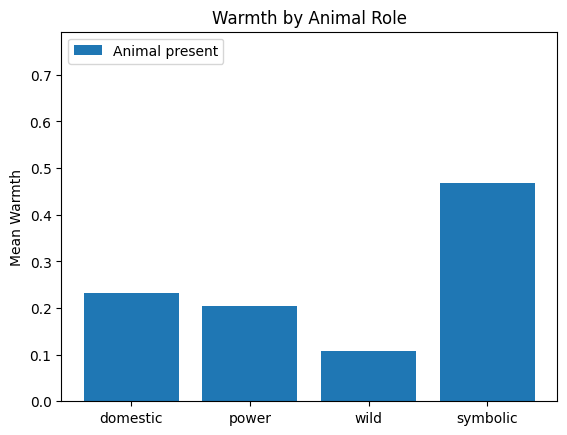

In [12]:
import matplotlib.pyplot as plt

animal_cols = ["domestic", "power", "wild", "symbolic"]

warmth_means_1 = []
warmth_means_0 = []

for col in animal_cols:
    warmth_means_1.append(df_h3[df_h3[col] == 1]["warmth"].mean())
    warmth_means_0.append(df_h3[df_h3[col] == 0]["warmth"].mean())

x = range(len(animal_cols))

plt.figure()
plt.bar(x, warmth_means_1, label="Animal present")
plt.bar(x, warmth_means_0, bottom=warmth_means_1, alpha=0)  # just for spacing

plt.xticks(x, animal_cols)
plt.ylabel("Mean Warmth")
plt.title("Warmth by Animal Role")
plt.legend()

plt.show()

<Figure size 640x480 with 0 Axes>

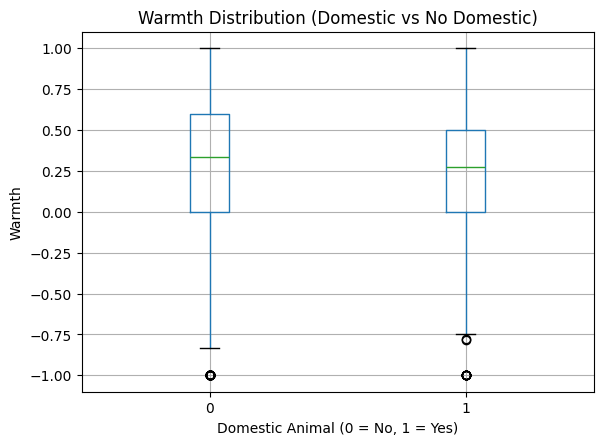

In [13]:
plt.figure()

df_h3.boxplot(column="warmth", by="domestic")

plt.title("Warmth Distribution (Domestic vs No Domestic)")
plt.suptitle("")
plt.xlabel("Domestic Animal (0 = No, 1 = Yes)")
plt.ylabel("Warmth")

plt.show()

<Figure size 640x480 with 0 Axes>

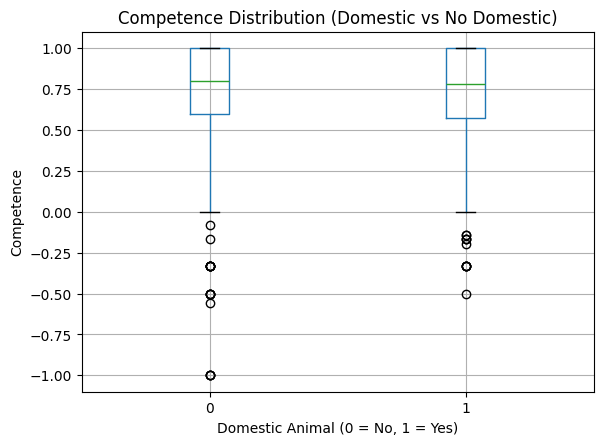

In [14]:
plt.figure()

df_h3.boxplot(column="competence", by="domestic")

plt.title("Competence Distribution (Domestic vs No Domestic)")
plt.suptitle("")
plt.xlabel("Domestic Animal (0 = No, 1 = Yes)")
plt.ylabel("Competence")

plt.show()

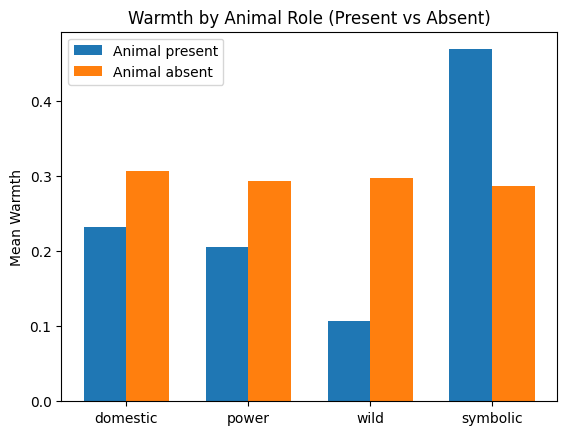

In [15]:
import matplotlib.pyplot as plt
import numpy as np

animal_cols = ["domestic", "power", "wild", "symbolic"]

means_1 = []
means_0 = []

for col in animal_cols:
    means_1.append(df_h3[df_h3[col] == 1]["warmth"].mean())
    means_0.append(df_h3[df_h3[col] == 0]["warmth"].mean())

x = np.arange(len(animal_cols))
width = 0.35

plt.figure()
plt.bar(x - width/2, means_1, width, label="Animal present")
plt.bar(x + width/2, means_0, width, label="Animal absent")

plt.xticks(x, animal_cols)
plt.ylabel("Mean Warmth")
plt.title("Warmth by Animal Role (Present vs Absent)")
plt.legend()

plt.show()

Two complementary comparisons were conducted. First, we compared artworks containing any animals to those without animals. Second, we differentiated between types of animals (domestic, wild, symbolic, and power-related), comparing each category against all other artworks.

This distinction allows us to separate the general effect of animal presence from the more nuanced influence of specific animal roles.

## H3 – Contextual Refinement of Animal Roles

To address the advisor’s comment, this section explores whether animal meaning can be refined beyond broad taxonomic categories.

The goal is to distinguish not only between types of animals, but also between their contextual role in the scene. For example, a dog may function as a companion animal or as a hunting animal, and a wild animal may appear as a threat or as a symbolic figure.

We begin by searching for context-related keywords in the textual descriptions of paintings containing fauna.

In [20]:
context_keywords = {
    "hunting_war": [
        "caza", "cazador", "cazando", "montería", "halcón", "halcon",
        "guerra", "batalla", "militar", "ejército", "ejercito",
        "arma", "armas", "caballería", "caballeria"
    ],
    "threat_attack": [
        "ataque", "ataca", "atacando", "devora", "muerde", "amenaza",
        "fiera", "peligro", "monstruo", "serpiente"
    ],
    "companion_calm": [
        "acompaña", "acompaña", "acompañado", "acompañado",
        "junto", "al lado", "bajo el brazo", "mascota", "perrillo",
        "reposa", "descansa"
    ]
}

fauna_desc = df_h3[df_h3["is_fauna"] == 1][["cat_no", "titulo", "descripcion"]].copy()
fauna_desc["descripcion"] = fauna_desc["descripcion"].fillna("").str.lower()

for group, words in context_keywords.items():
    pattern = "|".join(words)
    matched = fauna_desc[fauna_desc["descripcion"].str.contains(pattern, regex=True, na=False)]
    
    print(f"\n=== {group.upper()} ===")
    print("Matched paintings:", matched["cat_no"].nunique())
    print(matched[["cat_no", "titulo"]].head(10).to_string(index=False))


=== HUNTING_WAR ===
Matched paintings: 278
 cat_no                           titulo
P000002               El juicio de Paris
P000031                         Invierno
P000086                El viaje de Jacob
P000088    Diógenes buscando a un hombre
P000091            Elefantes en un circo
P000093     Soldados romanos en el circo
P000104 Alegoría de la Justicia y la Paz
P000122               Fiestas Lupercales
P000139                          Batalla
P000150                           Cupido

=== THREAT_ATTACK ===
Matched paintings: 93
 cat_no                                                      titulo
P000185 Rendición del ejército francés en la Batalla de San Quintín
P000195                                                   Andrómeda
P000209                                                   Cleopatra
P000426                                                      Sísifo
P000427                                                       Ticio
P000429                                             

### H3 – Contextual Animal Roles

To refine the hypothesis, animal roles are defined not only by type (e.g., domestic or wild), but also by their contextual function within the scene.

Contextual roles are inferred using keywords from artwork descriptions, allowing us to distinguish between:

- Companion animals: domestic animals in calm or relational contexts
- Hunting/war animals: animals associated with hunting, battle, or military settings
- Threat animals: animals depicted in aggressive or dangerous situations

This approach captures the idea that the same animal may convey different meanings depending on its narrative role.

In [21]:
# Create helper column for context detection
desc = df_h3["descripcion"].fillna("").str.lower()

# Hunting / war
df_h3["hunting_war"] = desc.str.contains(
    "caza|cazador|montería|halcón|halcon|guerra|batalla|militar|arma|caballería",
    regex=True
).astype(int)

# Threat / attack
df_h3["threat"] = desc.str.contains(
    "ataque|ataca|devora|muerde|fiera|peligro|monstruo|serpiente",
    regex=True
).astype(int)

# Companion = domestic + NOT hunting + NOT threat
df_h3["companion"] = (
    (df_h3["domestic"] == 1) &
    (df_h3["hunting_war"] == 0) &
    (df_h3["threat"] == 0)
).astype(int)

print(df_h3[["companion", "hunting_war", "threat"]].sum())

companion      471
hunting_war    659
threat         125
dtype: int64


### Statistical Testing – Contextual Animal Roles

We now test whether different contextual roles of animals are associated with differences in perceived warmth and competence.

Each role is compared against all other artworks, allowing us to isolate its specific effect.

In [22]:
from scipy.stats import ttest_ind
import numpy as np

def cohens_d(a, b):
    return (a.mean() - b.mean()) / np.sqrt((a.std()**2 + b.std()**2) / 2)

roles = ["companion", "hunting_war", "threat"]

for col in roles:
    print(f"\n=== {col.upper()} ===")
    
    group1 = df_h3[df_h3[col] == 1]
    group0 = df_h3[df_h3[col] == 0]
    
    # Warmth
    w1 = group1["warmth"]
    w0 = group0["warmth"]
    
    t_w, p_w = ttest_ind(w1, w0, equal_var=False)
    d_w = cohens_d(w1, w0)
    
    print("\nWARMTH")
    print(f"{col}=1 mean: {w1.mean():.3f}")
    print(f"{col}=0 mean: {w0.mean():.3f}")
    print(f"t={t_w:.3f}, p={p_w:.5f}, d={d_w:.3f}")
    
    # Competence
    c1 = group1["competence"]
    c0 = group0["competence"]
    
    t_c, p_c = ttest_ind(c1, c0, equal_var=False)
    d_c = cohens_d(c1, c0)
    
    print("\nCOMPETENCE")
    print(f"{col}=1 mean: {c1.mean():.3f}")
    print(f"{col}=0 mean: {c0.mean():.3f}")
    print(f"t={t_c:.3f}, p={p_c:.5f}, d={d_c:.3f}")


=== COMPANION ===

WARMTH
companion=1 mean: 0.294
companion=0 mean: 0.290
t=0.210, p=0.83359, d=0.010

COMPETENCE
companion=1 mean: 0.721
companion=0 mean: 0.754
t=-2.211, p=0.02741, d=-0.116

=== HUNTING_WAR ===

WARMTH
hunting_war=1 mean: 0.200
hunting_war=0 mean: 0.314
t=-6.119, p=0.00000, d=-0.266

COMPETENCE
hunting_war=1 mean: 0.745
hunting_war=0 mean: 0.750
t=-0.479, p=0.63215, d=-0.021

=== THREAT ===

WARMTH
threat=1 mean: -0.082
threat=0 mean: 0.306
t=-11.922, p=0.00000, d=-0.990

COMPETENCE
threat=1 mean: 0.701
threat=0 mean: 0.751
t=-2.653, p=0.00889, d=-0.208


### Interpretation of Contextual Animal Roles

The refined analysis reveals that the effect of animals on perceived warmth and competence depends strongly on their contextual role within the scene.

Companion animals do not significantly increase perceived warmth, suggesting that their presence alone is not sufficient to convey positive social signals. In contrast, animals associated with hunting or war contexts show a strong and significant decrease in warmth, indicating that these scenes are perceived as less socially positive.

Threat-related animals are associated with lower warmth and competence, reflecting their connection to danger and instability.

These findings support the idea that animal meaning in classical art is highly context-dependent. The same animal can convey different social signals depending on its narrative role, aligning with the hypothesis that visual perception is shaped not only by objects, but by their semantic function within the scene.

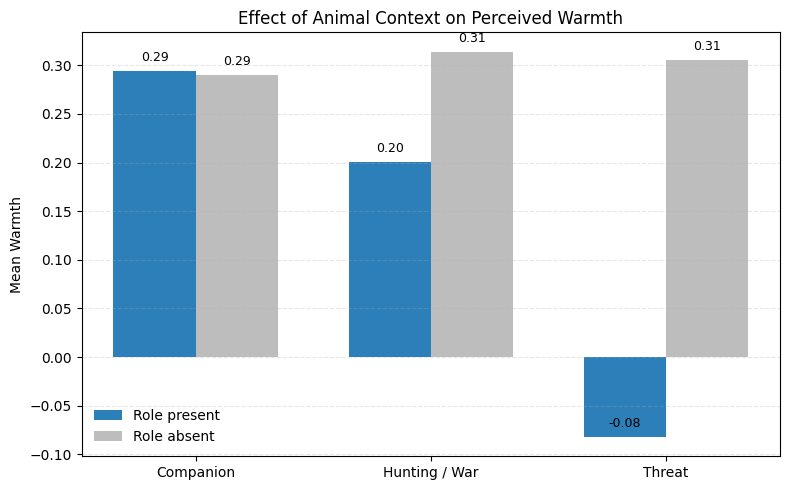

In [25]:
import matplotlib.pyplot as plt
import numpy as np

roles = ["Companion", "Hunting / War", "Threat"]

means_1 = []
means_0 = []

for col in ["companion", "hunting_war", "threat"]:
    means_1.append(df_h3[df_h3[col] == 1]["warmth"].mean())
    means_0.append(df_h3[df_h3[col] == 0]["warmth"].mean())

x = np.arange(len(roles))
width = 0.35

plt.figure(figsize=(8,5))

# Colors (semantic)
color_present = "#2C7FB8"   # blue
color_absent = "#BDBDBD"    # grey

bars1 = plt.bar(x - width/2, means_1, width, label="Role present", color=color_present)
bars2 = plt.bar(x + width/2, means_0, width, label="Role absent", color=color_absent)

# Labels
plt.xticks(x, roles)
plt.ylabel("Mean Warmth")
plt.title("Effect of Animal Context on Perceived Warmth")

# Grid
plt.grid(axis="y", linestyle="--", alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                 f"{height:.2f}", ha='center', fontsize=9)

plt.legend(frameon=False)

plt.tight_layout()
plt.show()

### Visualization of Contextual Animal Roles

Figure X illustrates how different contextual roles of animals are associated with perceived warmth. The comparison is made between artworks where a given role is present and those where it is absent.

Companion animals show almost no difference in warmth compared to the rest of the dataset, suggesting that their presence alone does not significantly influence perception. In contrast, animals associated with hunting or war contexts are linked to noticeably lower warmth values. This indicates that such scenes may be perceived as more conflict-oriented or less socially positive.

The strongest effect is observed for threat-related animals, which are associated with a substantial decrease in warmth. This aligns with the expectation that scenes involving danger or aggression reduce perceived warmth.

Overall, these results support the idea that the impact of animals in classical artworks depends more on their contextual role within the scene than on their mere presence.

### Regression Models for Contextual Animal Roles

In addition to mean comparisons, linear regression models are estimated to evaluate the association between contextual animal roles and the SCM dimensions of warmth and competence simultaneously.

This allows us to assess whether companion, hunting/war, and threat-related roles have distinct effects when considered together in the same model.

In [27]:
!pip install statsmodels

  Using cached statsmodels-0.14.6-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (9.5 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
Using cached statsmodels-0.14.6-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (10.3 MB)
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)


In [28]:
import statsmodels.formula.api as smf

# Warmth model
model_w = smf.ols(
    "warmth ~ companion + hunting_war + threat",
    data=df_h3
).fit()

# Competence model
model_c = smf.ols(
    "competence ~ companion + hunting_war + threat",
    data=df_h3
).fit()

print("=== WARMTH MODEL ===")
print(model_w.summary())

print("\n\n=== COMPETENCE MODEL ===")
print(model_c.summary())

=== WARMTH MODEL ===
                            OLS Regression Results                            
Dep. Variable:                 warmth   R-squared:                       0.041
Model:                            OLS   Adj. R-squared:                  0.040
Method:                 Least Squares   F-statistic:                     45.20
Date:                Fri, 03 Apr 2026   Prob (F-statistic):           1.34e-28
Time:                        14:25:56   Log-Likelihood:                -1779.0
No. Observations:                3198   AIC:                             3566.
Df Residuals:                    3194   BIC:                             3590.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.3340      0

### Regression Analysis of Contextual Animal Roles

The regression results confirm that contextual animal roles have distinct effects on perceived warmth.

Hunting and war-related animals are associated with a significant decrease in warmth, while threat-related animals show a much stronger negative effect. In fact, threat-related scenes produce the largest reduction in warmth across all roles.

Companion animals, on the other hand, do not have a statistically significant effect when controlling for other roles, suggesting that their presence alone does not meaningfully influence perception.

Overall, these results reinforce the idea that the social meaning of animals in classical artworks depends on their narrative role rather than their mere presence.

In [29]:
import pandas as pd

# Build a compact summary table for both models
summary_rows = []

for outcome_name, model in [("Warmth", model_w), ("Competence", model_c)]:
    coefs = model.params
    pvals = model.pvalues
    conf = model.conf_int()
    
    for var in ["companion", "hunting_war", "threat"]:
        summary_rows.append({
            "Outcome": outcome_name,
            "Role": var,
            "Coefficient": coefs[var],
            "CI_low": conf.loc[var, 0],
            "CI_high": conf.loc[var, 1],
            "p_value": pvals[var],
            "Significant": "Yes" if pvals[var] < 0.05 else "No"
        })

regression_summary = pd.DataFrame(summary_rows)

# Make it prettier
regression_summary["Coefficient"] = regression_summary["Coefficient"].round(3)
regression_summary["CI_low"] = regression_summary["CI_low"].round(3)
regression_summary["CI_high"] = regression_summary["CI_high"].round(3)
regression_summary["p_value"] = regression_summary["p_value"].round(5)

print(regression_summary.to_string(index=False))

   Outcome        Role  Coefficient  CI_low  CI_high  p_value Significant
    Warmth   companion       -0.040  -0.082    0.003  0.06763          No
    Warmth hunting_war       -0.110  -0.147   -0.073  0.00000         Yes
    Warmth      threat       -0.380  -0.456   -0.304  0.00000         Yes
Competence   companion       -0.039  -0.066   -0.011  0.00532         Yes
Competence hunting_war       -0.011  -0.035    0.012  0.35231          No
Competence      threat       -0.054  -0.103   -0.006  0.02809         Yes


### Summary of Regression Results

Table X summarizes the regression results for the effect of contextual animal roles on perceived warmth and competence.

For warmth, both hunting/war and threat-related roles show significant negative effects. In particular, threat-related animals have the strongest impact, substantially reducing perceived warmth. Companion animals do not show a statistically significant effect on warmth.

For competence, companion animals are associated with a small but significant decrease. Threat-related animals also reduce competence, although the effect is more moderate. In contrast, hunting/war contexts do not have a significant impact on competence.

Overall, these results reinforce the conclusion that the contextual role of animals influences perception in different ways depending on the dimension considered. While threat consistently reduces both warmth and competence, hunting contexts primarily affect warmth, and companion animals show limited influence.

In [32]:
import os

os.makedirs("Results", exist_ok=True)

In [33]:
regression_summary.to_csv("Results/regression_summary_h3.csv", index=False)